In [1]:
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import os
import liana as li
from liana.method import cellphonedb, cellchat
from tqdm import tqdm
#liana dotplot returns a ggsave object...
from plotnine import ggsave, ggplot
import warnings
warnings.filterwarnings("ignore")

In [2]:
h_cc_data = sc.read_h5ad("ProcessedData/Healthy_CellChat.h5ad")
d_cc_data = sc.read_h5ad("ProcessedData/Disease_CellChat.h5ad")
h_cpdb_data = sc.read_h5ad("ProcessedData/Healthy_CellPhoneDB.h5ad")
d_cpdb_data = sc.read_h5ad("ProcessedData/Disease_CellPhoneDB.h5ad")

In [14]:
cc_score = {}
for t in ["h","d"]:
    if t == "h":
        data = h_cc_data
    else:
        data = d_cc_data
    for s in ['cDC1s','cDC2s','Mig. cDCs','pDCs']:
        for l in ['H2-Aa','H2-Ab1']:
            for r in ['Cd4', 'Lag3']:
                x = data.uns["cpdb_res"][data.uns["cpdb_res"].ligand == l]\
                [data.uns["cpdb_res"].receptor == r]\
                [data.uns["cpdb_res"].target == 'T cells']\
                [data.uns["cpdb_res"].source == s]
                if x.empty:
                    cc_score[(t, s, l, r)] = 0
                else:
                    cc_score[(t, s, l, r)] = x.lr_probs.iloc[0]

cpdb_score = {}
for t in ["h","d"]:
    if t == "h":
        data = h_cpdb_data
    else:
        data = d_cpdb_data
    for s in ['cDC1s','cDC2s','Mig. cDCs','pDCs']:
        for l in ['H2-Aa','H2-Ab1']:
            for r in ['Cd4', 'Lag3']:
                x = data.uns["cpdb_res"][data.uns["cpdb_res"].ligand == l]\
                [data.uns["cpdb_res"].receptor == r]\
                [data.uns["cpdb_res"].target == 'T cells']\
                [data.uns["cpdb_res"].source == s]
                if x.empty:
                    cpdb_score[(t, s, l, r)] = 0
                else:
                    cpdb_score[(t, s, l, r)] = x.lr_means.iloc[0]

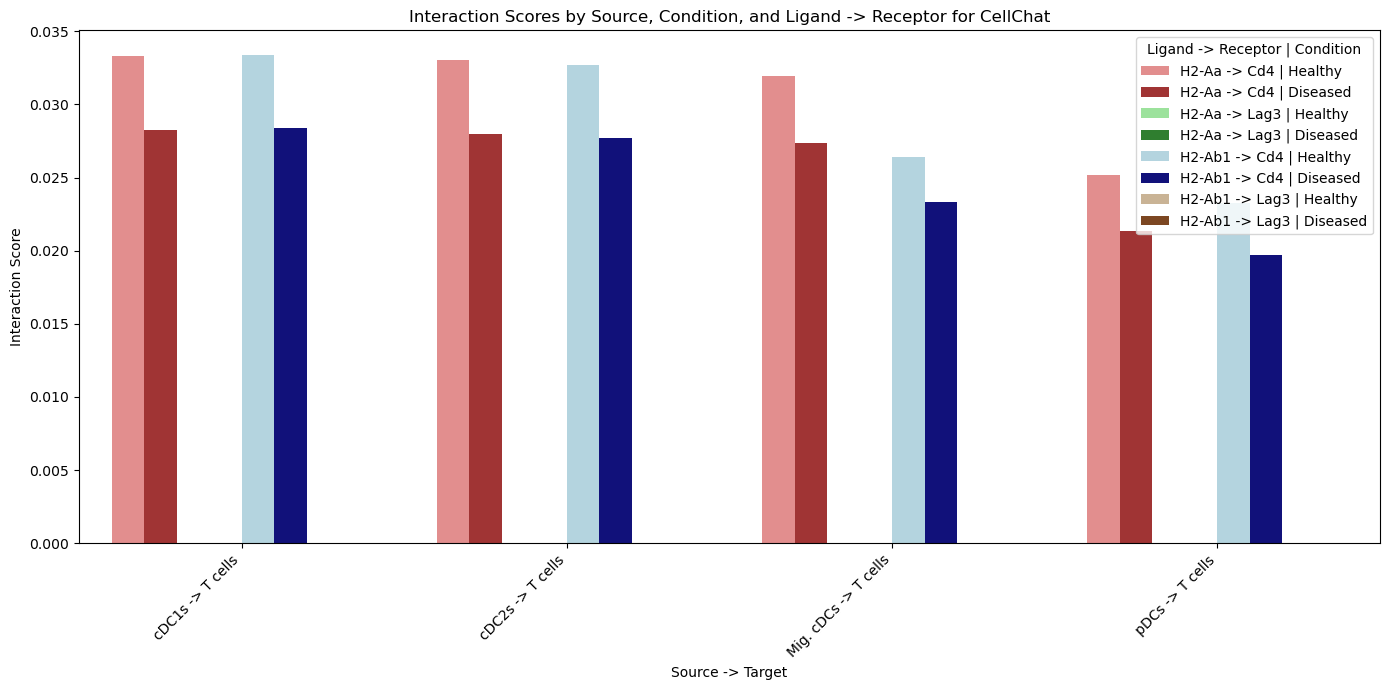

In [35]:
# Convert the dictionary to a DataFrame
df = pd.DataFrame(list(cc_score.items()), columns=['interactions', 'cc_score'])

# Split the 'interactions' tuple into separate columns
df[['Condition_Short', 'Source', 'Ligand', 'Receptor']] = pd.DataFrame(df['interactions'].tolist(), index=df.index)

# Replace short conditions with full names
df['Condition'] = df['Condition_Short'].replace({'h': 'Healthy', 'd': 'Diseased'})

# Create the Source -> Target column
df['Source -> Target'] = df['Source'] + ' -> T cells'

# Create the Ligand -> Receptor column
df['Ligand -> Receptor'] = df['Ligand'] + ' -> ' + df['Receptor']

# Create a combined column for the hue with the desired order
df['Legend'] = df['Ligand -> Receptor'] + ' | ' + df['Condition']

# Define the desired order of the hue categories with full condition names
hue_order = [
    'H2-Aa -> Cd4 | Healthy', 'H2-Aa -> Cd4 | Diseased',
    'H2-Aa -> Lag3 | Healthy', 'H2-Aa -> Lag3 | Diseased',
    'H2-Ab1 -> Cd4 | Healthy', 'H2-Ab1 -> Cd4 | Diseased',
    'H2-Ab1 -> Lag3 | Healthy', 'H2-Ab1 -> Lag3 | Diseased'
]

# Define the color palette
palette = {
    'H2-Aa -> Cd4 | Healthy': 'lightcoral',
    'H2-Aa -> Cd4 | Diseased': 'firebrick',
    'H2-Aa -> Lag3 | Healthy': 'lightgreen',
    'H2-Aa -> Lag3 | Diseased': 'forestgreen',
    'H2-Ab1 -> Cd4 | Healthy': 'lightblue',
    'H2-Ab1 -> Cd4 | Diseased': 'darkblue',
    'H2-Ab1 -> Lag3 | Healthy': 'tan',
    'H2-Ab1 -> Lag3 | Diseased': 'saddlebrown'
}

# Create the bar plot
plt.figure(figsize=(14, 7))
sns.barplot(x='Source -> Target', y='cc_score', hue='Legend', data=df, dodge=True, hue_order=hue_order, palette=palette)

# Add labels and title
plt.xlabel('Source -> Target')
plt.ylabel('Interaction Score')
plt.title('Interaction Scores by Source, Condition, and Ligand -> Receptor for CellChat')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.legend(title='Ligand -> Receptor | Condition')
plt.savefig('figures/CellChatAll_Compare.png')

# Show the plot
# plt.show()

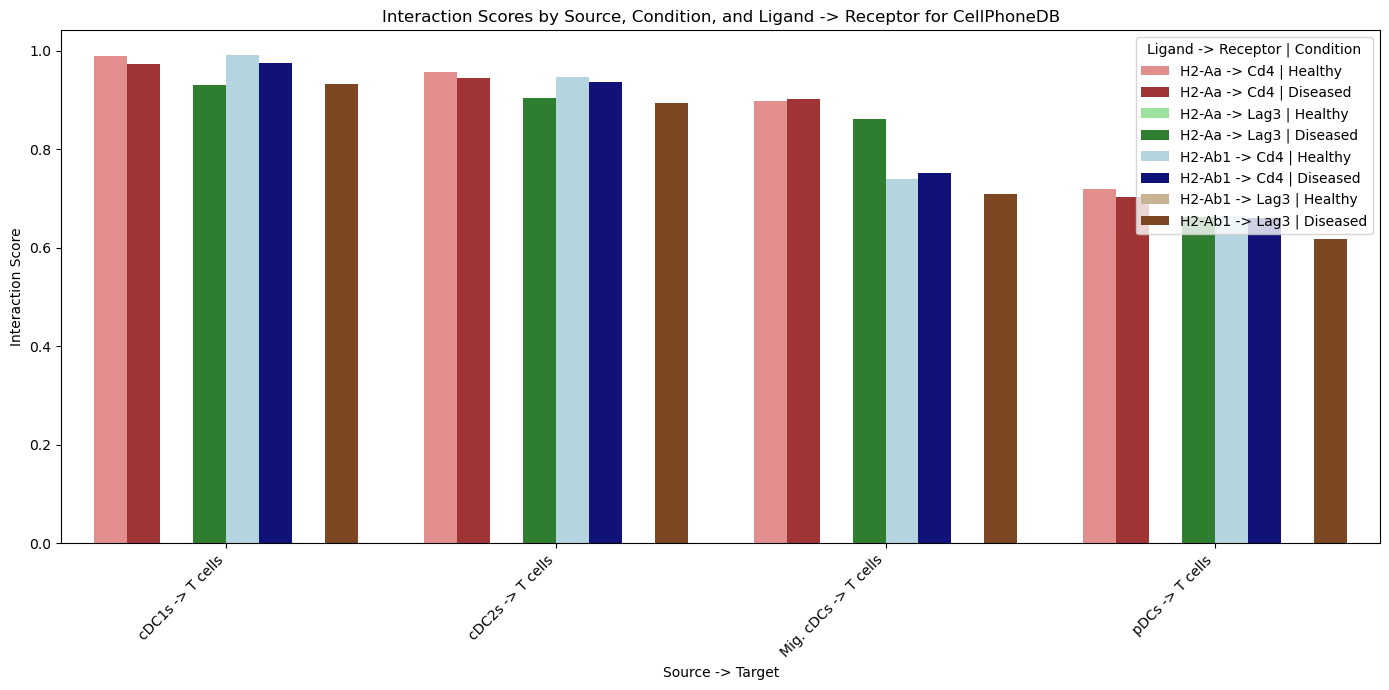

In [36]:
# Convert the dictionary to a DataFrame
df = pd.DataFrame(list(cpdb_score.items()), columns=['interactions', 'cc_score'])

# Split the 'interactions' tuple into separate columns
df[['Condition_Short', 'Source', 'Ligand', 'Receptor']] = pd.DataFrame(df['interactions'].tolist(), index=df.index)

# Replace short conditions with full names
df['Condition'] = df['Condition_Short'].replace({'h': 'Healthy', 'd': 'Diseased'})

# Create the Source -> Target column
df['Source -> Target'] = df['Source'] + ' -> T cells'

# Create the Ligand -> Receptor column
df['Ligand -> Receptor'] = df['Ligand'] + ' -> ' + df['Receptor']

# Create a combined column for the hue with the desired order
df['Legend'] = df['Ligand -> Receptor'] + ' | ' + df['Condition']

# Define the desired order of the hue categories with full condition names
hue_order = [
    'H2-Aa -> Cd4 | Healthy', 'H2-Aa -> Cd4 | Diseased',
    'H2-Aa -> Lag3 | Healthy', 'H2-Aa -> Lag3 | Diseased',
    'H2-Ab1 -> Cd4 | Healthy', 'H2-Ab1 -> Cd4 | Diseased',
    'H2-Ab1 -> Lag3 | Healthy', 'H2-Ab1 -> Lag3 | Diseased'
]

# Define the color palette
palette = {
    'H2-Aa -> Cd4 | Healthy': 'lightcoral',
    'H2-Aa -> Cd4 | Diseased': 'firebrick',
    'H2-Aa -> Lag3 | Healthy': 'lightgreen',
    'H2-Aa -> Lag3 | Diseased': 'forestgreen',
    'H2-Ab1 -> Cd4 | Healthy': 'lightblue',
    'H2-Ab1 -> Cd4 | Diseased': 'darkblue',
    'H2-Ab1 -> Lag3 | Healthy': 'tan',
    'H2-Ab1 -> Lag3 | Diseased': 'saddlebrown'
}

# Create the bar plot
plt.figure(figsize=(14, 7))
sns.barplot(x='Source -> Target', y='cc_score', hue='Legend', data=df, dodge=True, hue_order=hue_order, palette=palette)

# Add labels and title
plt.xlabel('Source -> Target')
plt.ylabel('Interaction Score')
plt.title('Interaction Scores by Source, Condition, and Ligand -> Receptor for CellPhoneDB')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.legend(title='Ligand -> Receptor | Condition')
plt.savefig('figures/CellPhoneDBAll_Compare.png')

# Show the plot
# plt.show()